# Theory Questions

1. Can we use Bagging for regression problems
   - Yes, Bagging can be used for regression problems.

2. What is the difference between multiple model training and single model training
   - Single model training uses only one machine learning model to learn from the training data and make predictions.

   - Multiple model training uses several models and combines their predictions to produce a final result
  
3. Explain the concept of feature randomness in Random Forest
   - Feature randomness means that each decision tree in a Random Forest considers only a random subset of features when deciding how to split a node.

     This makes the trees different from one another and reduces their correlation.

4. What is OOB (Out-of-Bag) Score
   - OOB Score is an evaluation method used in Bagging and Random Forest models that use bootstrap sampling.

5. How can you measure the importance of features in a Random Forest model
   - Common approaches include:

     - Mean Decrease in Impurity (MDI) — based on how much each feature reduces impurity across the trees.
     - Permutation Importance — measures how much model performance decreases when a feature's values are randomly shuffled.

6. Explain the working principle of a Bagging Classifier2
   - A Bagging Classifier works as follows:

     - Multiple bootstrap samples are created from the training dataset.
     - A separate base classifier is trained on each sample.
     - Each classifier makes a prediction for new data.
     - The predictions are combined using majority voting.
     - The class receiving the most votes becomes the final prediction.

7. How do you evaluate a Bagging Classifier’s performance
   - A Bagging Classifier can be evaluated using metrics such as:

     - Accuracy
     - Precision
     - Recall
     - F1-score
     - Confusion Matrix
     - ROC-AUC

8. How does a Bagging Regressor work
   - A Bagging Regressor trains multiple regression models on different bootstrap samples of the training dataset. Each model produces a numerical prediction. The final prediction is generally calculated by taking the average of the predictions.

9. What is the main advantage of ensemble techniques
   - The main advantage is that combining multiple models can produce better and more stable predictions than using a single model.

10. What is the main challenge of ensemble methods
    - The main challenges are:

      - Increased computational cost
      - More memory requirements
      - More complex models
      - Longer training time
      - Reduced interpretability compared with a single simple model

11. Explain the key idea behind ensemble techniques
    - The key idea is:

      Combine the predictions of multiple models to obtain a stronger and more reliable model.

12. What is a Random Forest Classifier
    - A Random Forest Classifier is an ensemble learning algorithm that combines multiple Decision Trees.

13. What are the main types of ensemble techniques
    - The major ensemble techniques are:

      - Bagging
      - Boosting
      - Stacking
      - Voting

14. What is ensemble learning in machine learning
    - Ensemble learning is a machine learning technique where multiple models are combined to create a stronger predictive model.

15. When should we avoid using ensemble methods
    - Ensemble methods may be avoided when:

      -The dataset is very small and a simple model performs well.
      - Computational resources are limited.
      - Fast predictions are extremely important.
      - Model interpretability is a major requirement.
      - A simple model already provides sufficient performance.

16. How does Bagging help in reducing overfitting
    - agging reduces overfitting mainly by reducing variance.

      It trains multiple models on different bootstrap samples. Since the models see different versions of the training data, their errors are less likely to be identical. Combining their predictions makes the final model more stable and less sensitive to variations in the training data.  

17. Why is Random Forest better than a single Decision Tree
    - Random Forest is often better because it combines many Decision Trees instead of relying on only one tree.

18. What is the role of bootstrap sampling in Bagging
    - Bootstrap sampling creates multiple training datasets by randomly selecting observations with replacement from the original dataset. Each model is trained on a different bootstrap sample.

19. What are some real-world applications of ensemble techniques
    - Ensemble techniques are widely used in:

      - Banking: Fraud detection
      - Finance: Credit risk prediction
      - Healthcare: Disease prediction
      - E-commerce: Recommendation systems
      - Marketing: Customer churn prediction
      - Cybersecurity: Intrusion detection
      - Real estate: House price prediction
      - Manufacturing: Predictive maintenance
      - Text classification: Spam detection
      - Computer vision: Image classification

20. What is the difference between Bagging and Boosting
    - Bagging
      - Models are generally trained independently/in parallel
      - Focuses mainly on reducing variance
      - Uses bootstrap samples
      - Models usually have equal importance in basic Bagging
      - Less sensitive to noisy observations

    - Boosting
      - Models are generally trained sequentially
      - Focuses mainly on reducing bias
      - Later models focus more on previous errors
      - Models can have different weights
      - Can be more sensitive to noise

# Practical Questions

1. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base_model = DecisionTreeClassifier(random_state=42)

model = BaggingClassifier(
    estimator=base_model,
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


2. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE)

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base_model = DecisionTreeRegressor(random_state=42)

model = BaggingRegressor(
    estimator=base_model,
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 3256.961797752809


3. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Feature Importance Scores:")

for feature, importance in zip(data.feature_names, model.feature_importances_):
    print(feature, ":", importance)

Feature Importance Scores:
mean radius : 0.048703371737755234
mean texture : 0.013590877656998469
mean perimeter : 0.053269746128179675
mean area : 0.04755500886018552
mean smoothness : 0.007285327830663239
mean compactness : 0.013944325074050485
mean concavity : 0.06800084191430111
mean concave points : 0.10620998844591638
mean symmetry : 0.003770291819290666
mean fractal dimension : 0.0038857721093275
radius error : 0.02013891719419153
texture error : 0.004723988073894702
perimeter error : 0.01130301388178435
area error : 0.022406960160458473
smoothness error : 0.004270910110504497
compactness error : 0.005253215538990106
concavity error : 0.009385832251596627
concave points error : 0.003513255105598506
symmetry error : 0.004018418617722808
fractal dimension error : 0.00532145634222884
worst radius : 0.07798687515738047
worst texture : 0.021749011006763207
worst perimeter : 0.06711483267839194
worst area : 0.15389236463205394
worst smoothness : 0.010644205147280952
worst compactness 

4. Train a Random Forest Regressor and compare its performance with a single Decision Tree

In [4]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_pred)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)

print("Decision Tree MSE:", dt_mse)
print("Random Forest MSE:", rf_mse)

Decision Tree MSE: 4976.797752808989
Random Forest MSE: 2952.0105887640448


5. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()

X = data.data
y = data.target

model = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    bootstrap=True,
    random_state=42
)

model.fit(X, y)

print("OOB Score:", model.oob_score_)

OOB Score: 0.961335676625659


6. Train a Bagging Classifier using SVM as a base estimator and print accuracy

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svm = SVC(kernel="linear")

model = BaggingClassifier(
    estimator=svm,
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


7. Train a Random Forest Classifier with different numbers of trees and compare accuracy

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for n in [10, 50, 100, 200]:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Number of Trees:", n)
    print("Accuracy:", accuracy)
    print()

Number of Trees: 10
Accuracy: 1.0

Number of Trees: 50
Accuracy: 1.0

Number of Trees: 100
Accuracy: 1.0

Number of Trees: 200
Accuracy: 1.0



8. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(max_iter=5000)

model = BaggingClassifier(
    estimator=lr,
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.99737962659679


9.  Train a Random Forest Regressor and analyze feature importance scores

In [9]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor

data = load_diabetes()

X = data.data
y = data.target

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

print("Feature Importance:")

for feature, importance in zip(data.feature_names, model.feature_importances_):
    print(feature, ":", importance)

Feature Importance:
age : 0.05749630990691616
sex : 0.011900939045372818
bmi : 0.2762487694420927
bp : 0.08708509584044875
s1 : 0.04725056648926529
s2 : 0.05536752264925017
s3 : 0.05119054384148261
s4 : 0.027055593119826065
s5 : 0.31562931724463833
s6 : 0.07077534242070717


10. Train an ensemble model using both Bagging and Random Forest and compare accuracy.

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

bag_accuracy = accuracy_score(y_test, bag_pred)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Bagging Accuracy:", bag_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Bagging Accuracy: 1.0
Random Forest Accuracy: 1.0


11. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV=

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Test Accuracy:", grid.score(X_test, y_test))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Accuracy: 0.95
Test Accuracy: 1.0


12.  Train a Bagging Regressor with different numbers of base estimators and compare performance

In [12]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for n in [5, 10, 50, 100]:

    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mse = mean_squared_error(y_test, prediction)

    print("Estimators:", n)
    print("MSE:", mse)
    print()

Estimators: 5
MSE: 3367.1020224719105

Estimators: 10
MSE: 3256.961797752809

Estimators: 50
MSE: 3056.494602247191

Estimators: 100
MSE: 2970.863235955056



13. Train a Random Forest Classifier and analyze misclassified samples

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test, index_train, index_test = train_test_split(
    X, y, range(len(y)), test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Misclassified Samples:")

for i in range(len(y_test)):
    if prediction[i] != y_test[i]:
        print(
            "Index:", index_test[i],
            "Actual:", y_test[i],
            "Predicted:", prediction[i]
        )

Misclassified Samples:


14. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier

In [14]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

# Bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)
bag_accuracy = accuracy_score(y_test, bag_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Bagging Accuracy:", bag_accuracy)

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


15. Train a Random Forest Classifier and visualize the confusion matrix

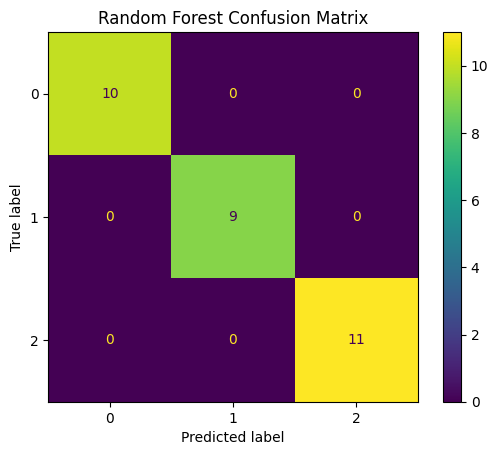

In [15]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Random Forest Confusion Matrix")
plt.show()

16.  Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True)),
    ('lr', LogisticRegression(max_iter=1000))
]

model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))

Stacking Accuracy: 1.0


17. Train a Random Forest Classifier and print the top 5 most important features

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()

X = data.data
y = data.target

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance = model.feature_importances_

features = list(zip(data.feature_names, importance))

features.sort(key=lambda x: x[1], reverse=True)

print("Top 5 Important Features:")

for feature, score in features[:5]:
    print(feature, ":", score)

Top 5 Important Features:
worst area : 0.13935694286788813
worst concave points : 0.13222508566399135
mean concave points : 0.10704565721708294
worst radius : 0.08284828183729644
worst perimeter : 0.08084969717184524


18. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score

In [18]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import classification_report

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



19.  Train a Random Forest Classifier and analyze the effect of max_depth on accuracy

In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for depth in [2, 3, 5, 10, None]:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Max Depth:", depth)
    print("Accuracy:", accuracy)
    print()

Max Depth: 2
Accuracy: 1.0

Max Depth: 3
Accuracy: 1.0

Max Depth: 5
Accuracy: 1.0

Max Depth: 10
Accuracy: 1.0

Max Depth: None
Accuracy: 1.0



20.  Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance

In [20]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree Bagging
tree_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mse = mean_squared_error(y_test, tree_pred)

# KNN Bagging
knn_model = BaggingRegressor(
    estimator=KNeighborsRegressor(n_neighbors=5),
    n_estimators=50,
    random_state=42
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_mse = mean_squared_error(y_test, knn_pred)

print("Decision Tree Bagging MSE:", tree_mse)
print("KNN Bagging MSE:", knn_mse)

Decision Tree Bagging MSE: 3056.494602247191
KNN Bagging MSE: 2918.7794793707876


21. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9952505732066819


22. Train a Bagging Classifier and evaluate its performance using cross-validation

In [22]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

X, y = load_iris(return_X_y=True)

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", scores)
print("Average Accuracy:", scores.mean())

Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average Accuracy: 0.9666666666666668


23.  Train a Random Forest Classifier and plot the Precision-Recall curve

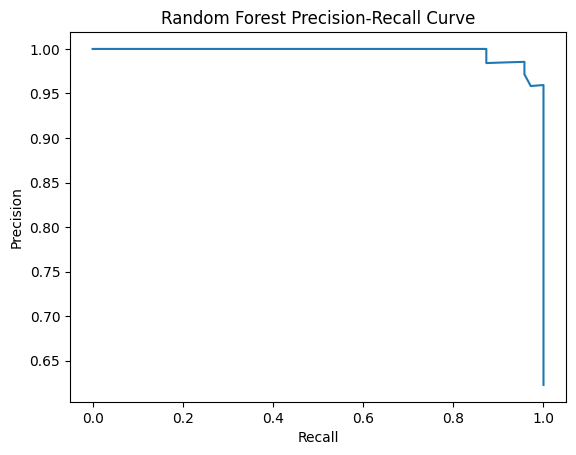

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test, y_prob
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.show()

24. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy

In [24]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

stacking = StackingClassifier(
    estimators=[
        ('rf', rf)
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

# Random Forest
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

# Stacking
stacking.fit(X_train, y_train)
stack_pred = stacking.predict(X_test)

stack_accuracy = accuracy_score(y_test, stack_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Stacking Accuracy:", stack_accuracy)

Random Forest Accuracy: 1.0
Stacking Accuracy: 1.0


25.  Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

In [25]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for max_samples in [0.5, 0.7, 1.0]:

    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=50,
        max_samples=max_samples,
        bootstrap=True,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    print("Bootstrap Sample Level:", max_samples)
    print("MSE:", mse)
    print()

Bootstrap Sample Level: 0.5
MSE: 2997.33242247191

Bootstrap Sample Level: 0.7
MSE: 3087.5079820224723

Bootstrap Sample Level: 1.0
MSE: 3056.494602247191

